Mel Spectrogram shape: torch.Size([4443, 16])
MFCC shape: torch.Size([4443, 16])
RMS Energy shape: torch.Size([4443, 1])
Pitch shape: torch.Size([4443, 1])
Energy Derivatives shape: torch.Size([4443, 1])
Pitch Derivatives shape: torch.Size([4443, 1])
Onsets shape: torch.Size([4443, 1])
WavLM Features shape: torch.Size([4443, 768])
Mel Spectrogram max: 733.3438110351562, min: 0.0, mean: 5.993409156799316, std: 20.66299819946289
MFCC max: 87.47040557861328, min: -137.42698669433594, mean: 4.184473991394043, std: 23.091190338134766
RMS Energy max: 0.317769855260849, min: 9.999999747378752e-06, mean: 0.11385506391525269, std: 0.021795006468892097
Pitch max: 2666.666748046875, min: 0.0, mean: 1214.797607421875, std: 968.9879760742188
Energy Derivatives max: 0.07880392670631409, min: -0.0653008297085762, mean: 6.3231500462279655e-06, std: 0.0037832625675946474
Pitch Derivatives max: 2519.877685546875, min: -2450.450439453125, mean: -0.6001951098442078, std: 266.28472900390625
Onsets max: 1.0

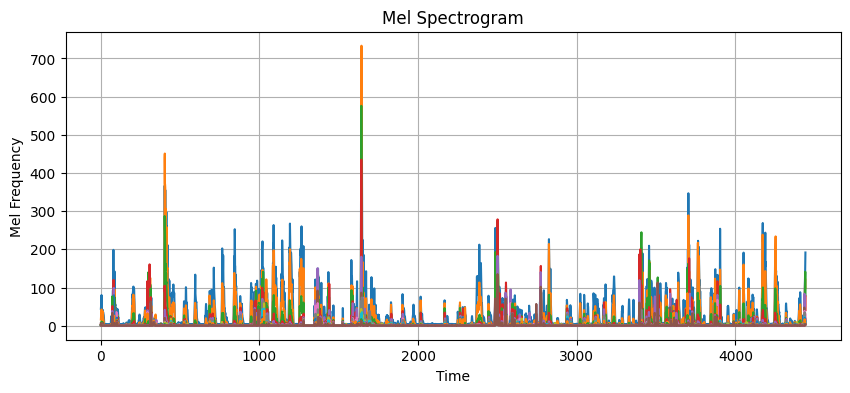

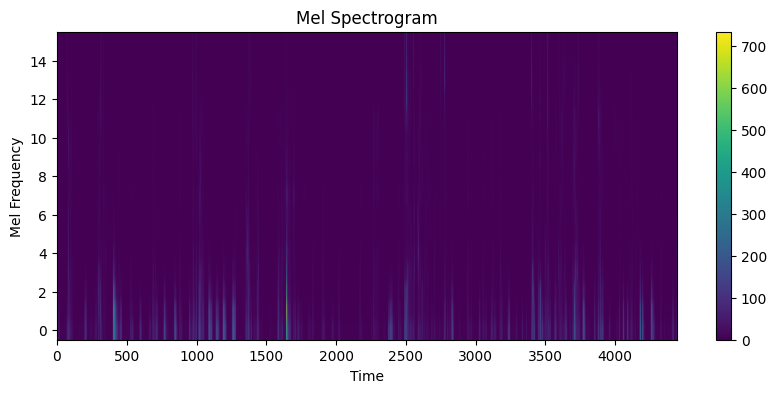

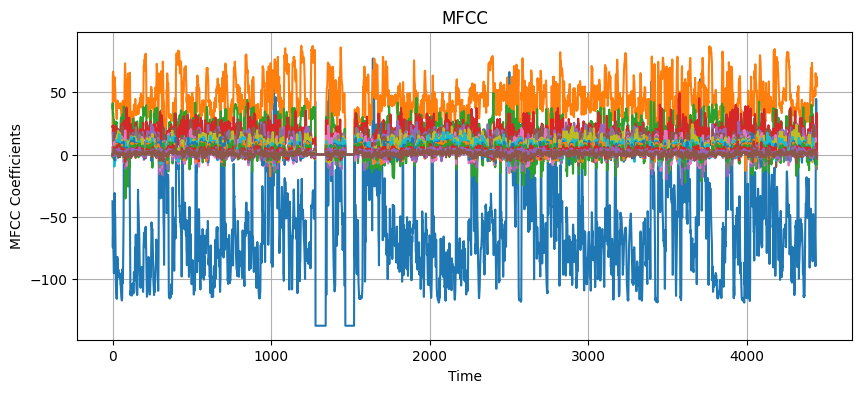

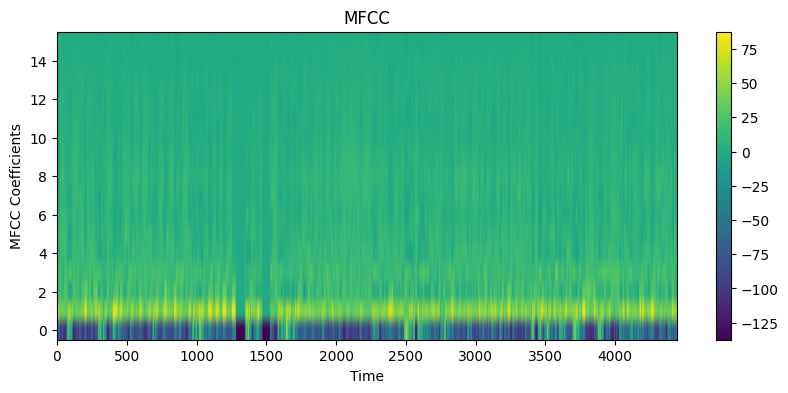

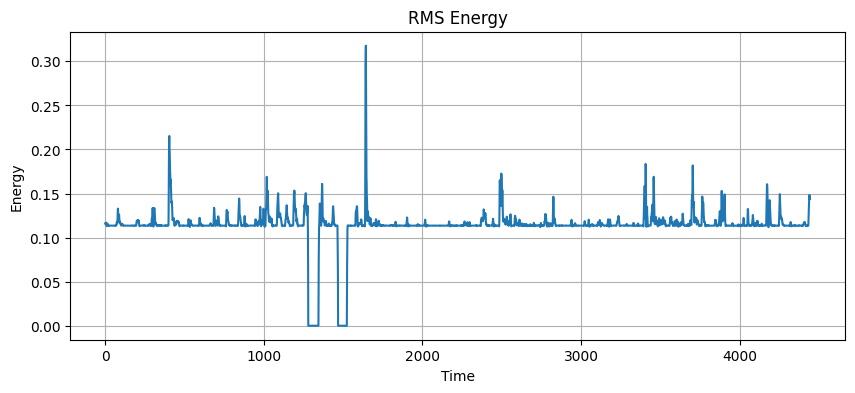

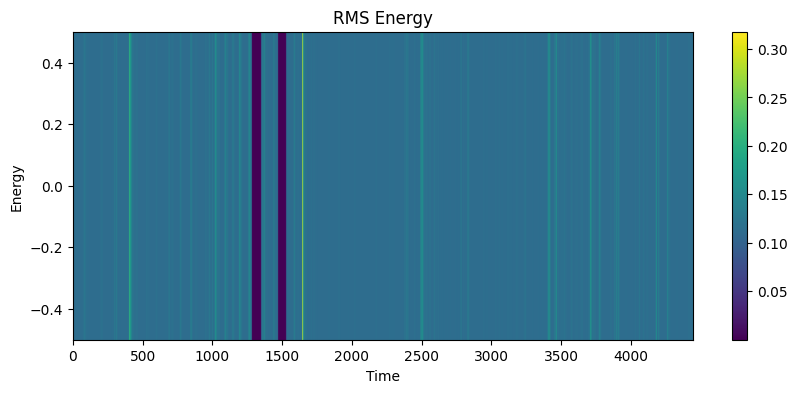

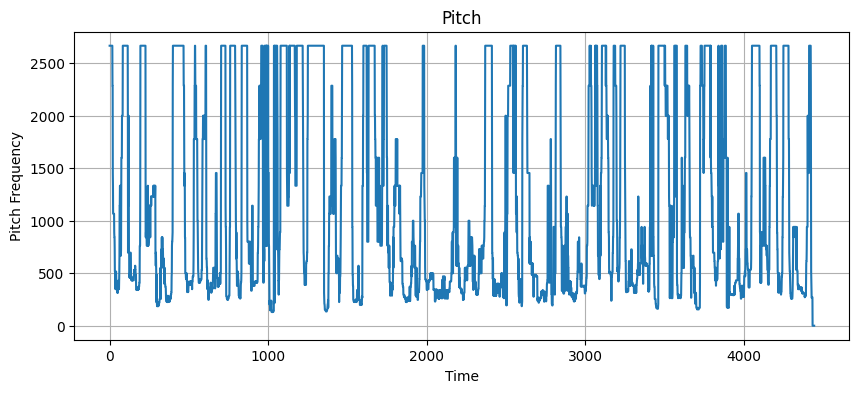

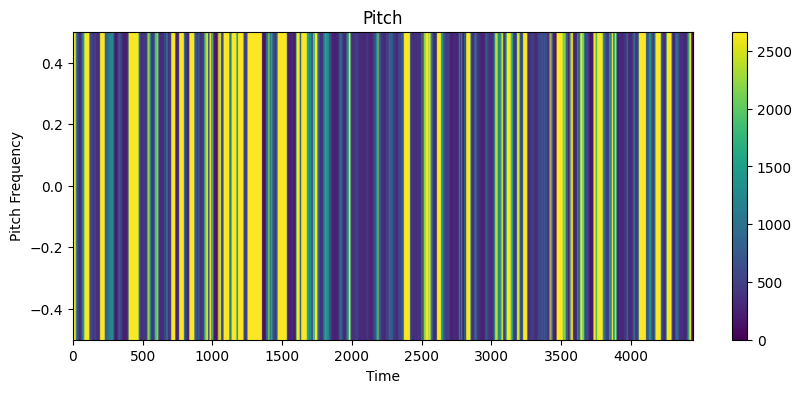

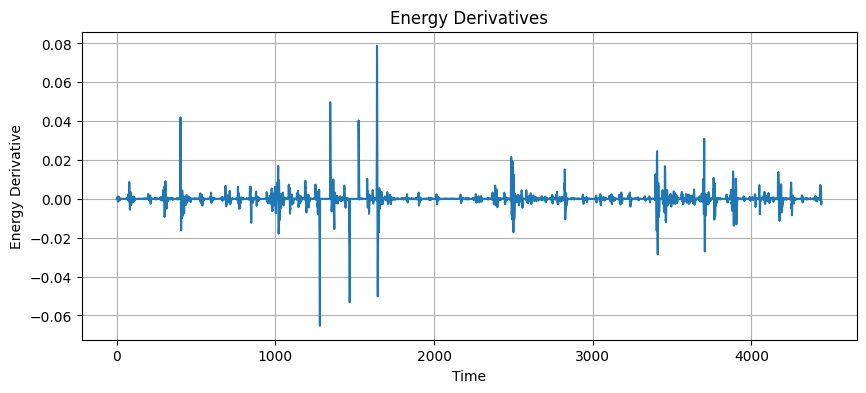

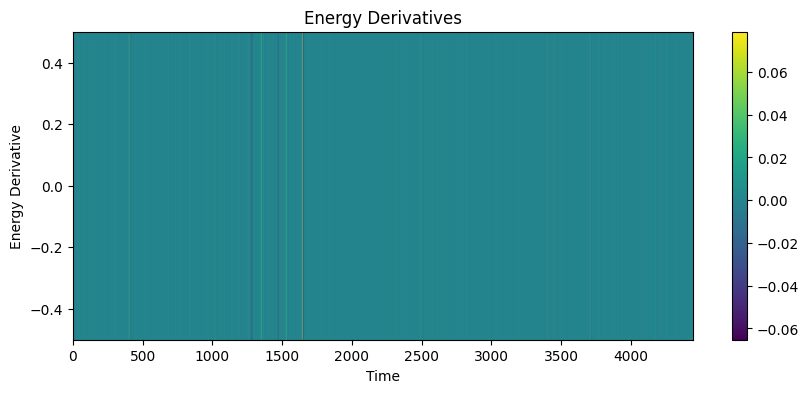

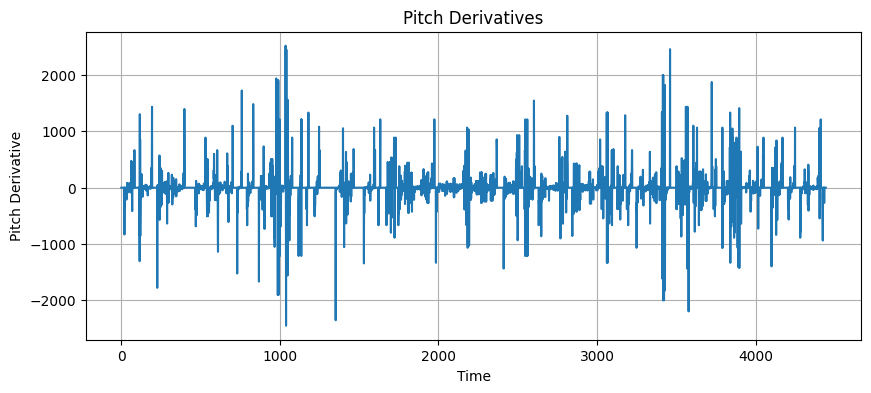

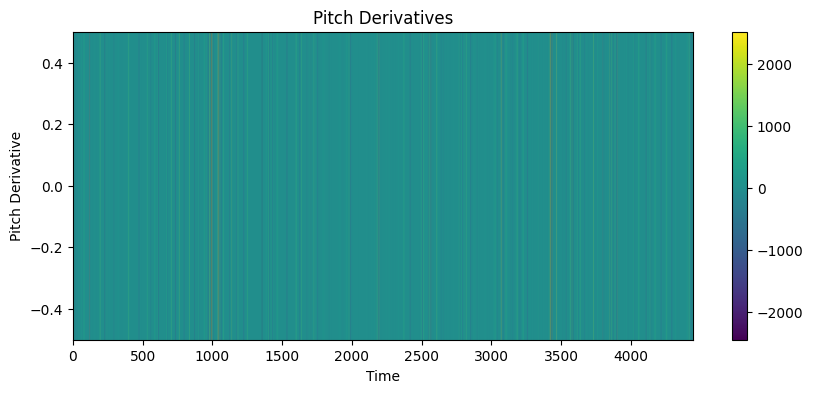

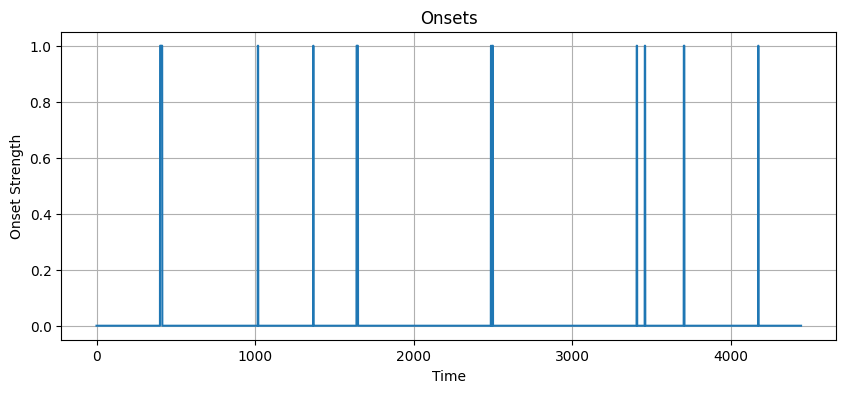

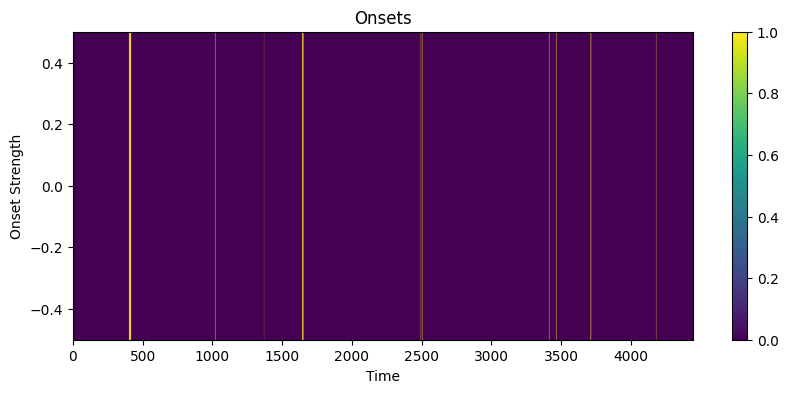

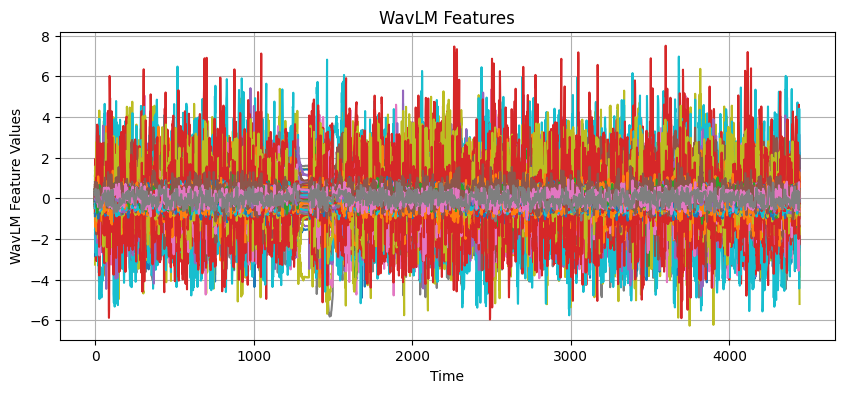

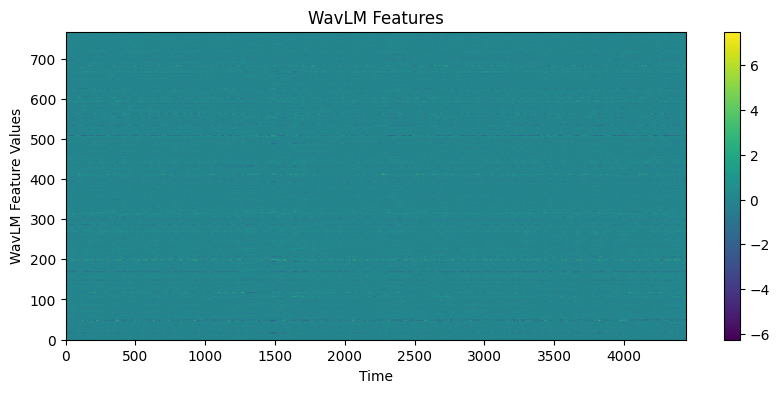

In [5]:
from utils.audio_processing.extract_audio_features import extract_audio_features
import os

wav_dir = 'dataset/genea2023_dataset/toy/main-agent/wav'
wav_file = 'trn_2023_v0_004_main-agent.wav'

# Extract audio features
wav_path = os.path.join(wav_dir, wav_file)
mel_spec, mfcc, rms_energy, pitch, energy_derivatives, pitch_derivatives, onsets, wavlm_features = extract_audio_features(wav_path)

print(f"Mel Spectrogram shape: {mel_spec.shape}")
print(f"MFCC shape: {mfcc.shape}")
print(f"RMS Energy shape: {rms_energy.shape}")
print(f"Pitch shape: {pitch.shape}")
print(f"Energy Derivatives shape: {energy_derivatives.shape}")
print(f"Pitch Derivatives shape: {pitch_derivatives.shape}")
print(f"Onsets shape: {onsets.shape}")
print(f"WavLM Features shape: {wavlm_features.shape}")

# prim max, min, mean, std
print(f"Mel Spectrogram max: {mel_spec.max()}, min: {mel_spec.min()}, mean: {mel_spec.mean()}, std: {mel_spec.std()}")
print(f"MFCC max: {mfcc.max()}, min: {mfcc.min()}, mean: {mfcc.mean()}, std: {mfcc.std()}")
print(f"RMS Energy max: {rms_energy.max()}, min: {rms_energy.min()}, mean: {rms_energy.mean()}, std: {rms_energy.std()}")
print(f"Pitch max: {pitch.max()}, min: {pitch.min()}, mean: {pitch.mean()}, std: {pitch.std()}")
print(f"Energy Derivatives max: {energy_derivatives.max()}, min: {energy_derivatives.min()}, mean: {energy_derivatives.mean()}, std: {energy_derivatives.std()}")
print(f"Pitch Derivatives max: {pitch_derivatives.max()}, min: {pitch_derivatives.min()}, mean: {pitch_derivatives.mean()}, std: {pitch_derivatives.std()}")
print(f"Onsets max: {onsets.max()}, min: {onsets.min()}, mean: {onsets.mean()}, std: {onsets.std()}")
print(f"WavLM Features max: {wavlm_features.max()}, min: {wavlm_features.min()}, mean: {wavlm_features.mean()}, std: {wavlm_features.std()}")

# Draw each feature in a separate figure
import matplotlib.pyplot as plt
import numpy as np

def plot_feature(feature, title, xlabel, ylabel):
    plt.figure(figsize=(10, 4))
    plt.plot(feature)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid()
    plt.show()

    # Draw as image
    plt.figure(figsize=(10, 4))
    plt.imshow(feature.T, aspect='auto', origin='lower')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.colorbar()
    plt.show()


plot_feature(mel_spec.cpu().numpy(), 'Mel Spectrogram', 'Time', 'Mel Frequency')
plot_feature(mfcc.cpu().numpy(), 'MFCC', 'Time', 'MFCC Coefficients')
plot_feature(rms_energy.cpu().numpy(), 'RMS Energy', 'Time', 'Energy')
plot_feature(pitch.cpu().numpy(), 'Pitch', 'Time', 'Pitch Frequency')
plot_feature(energy_derivatives.cpu().numpy(), 'Energy Derivatives', 'Time', 'Energy Derivative')
plot_feature(pitch_derivatives.cpu().numpy(), 'Pitch Derivatives', 'Time', 'Pitch Derivative')
plot_feature(onsets.cpu().numpy(), 'Onsets', 'Time', 'Onset Strength')
plot_feature(wavlm_features.cpu().numpy(), 'WavLM Features', 'Time', 'WavLM Feature Values')

Gestures shape: torch.Size([49628, 345])
Mel Spectrogram shape: torch.Size([49628, 16])
MFCC shape: torch.Size([49628, 16])
RMS Energy shape: torch.Size([49628, 1])
Pitch shape: torch.Size([49628, 1])
Energy Derivatives shape: torch.Size([49628, 1])
Pitch Derivatives shape: torch.Size([49628, 1])
Onsets shape: torch.Size([49628, 1])
WavLM Features shape: torch.Size([49628, 768])
Speakers shape: torch.Size([11, 17])


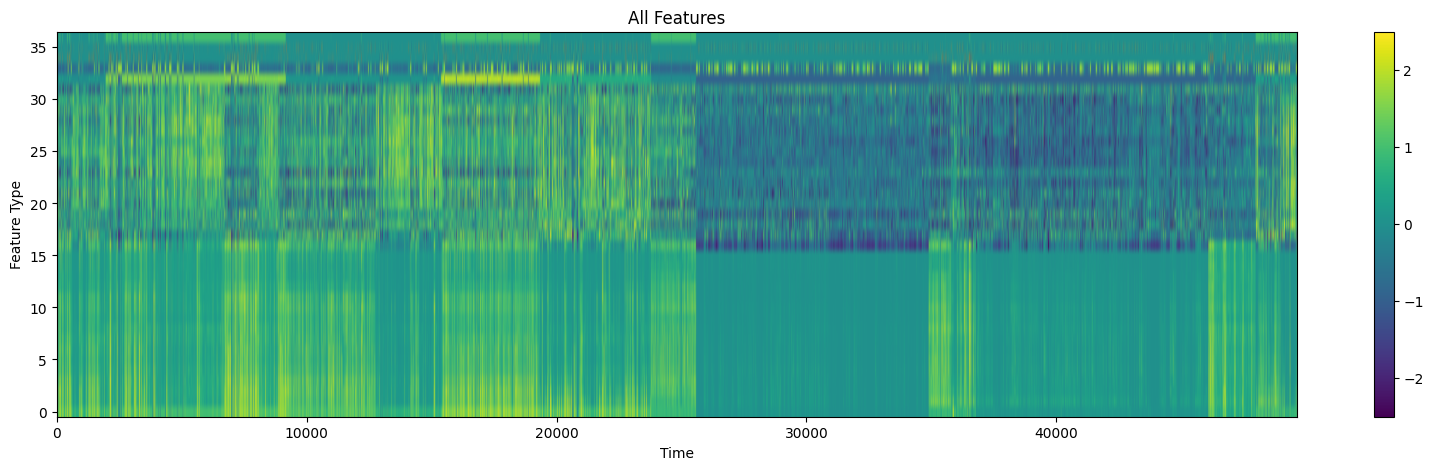

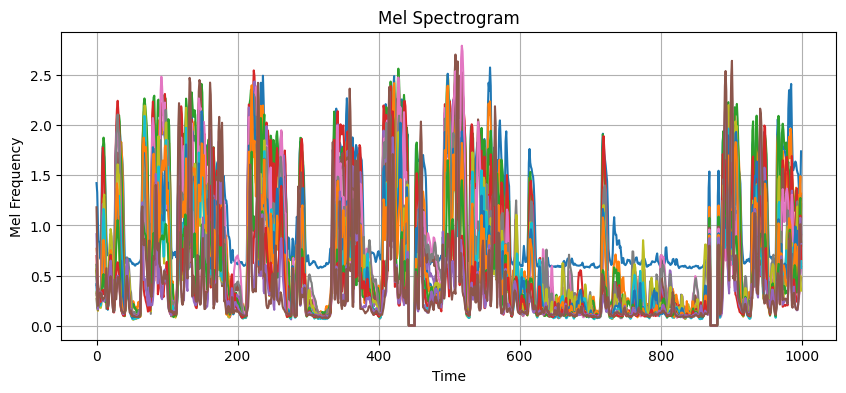

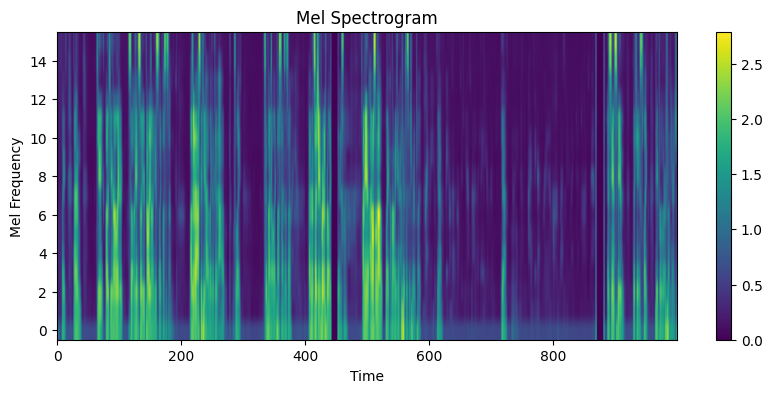

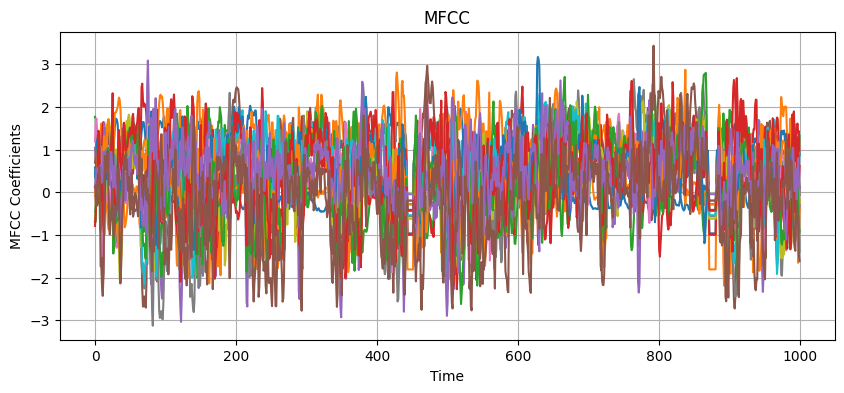

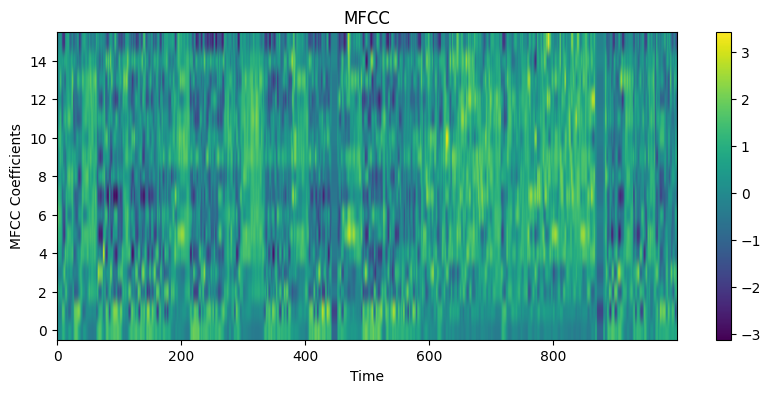

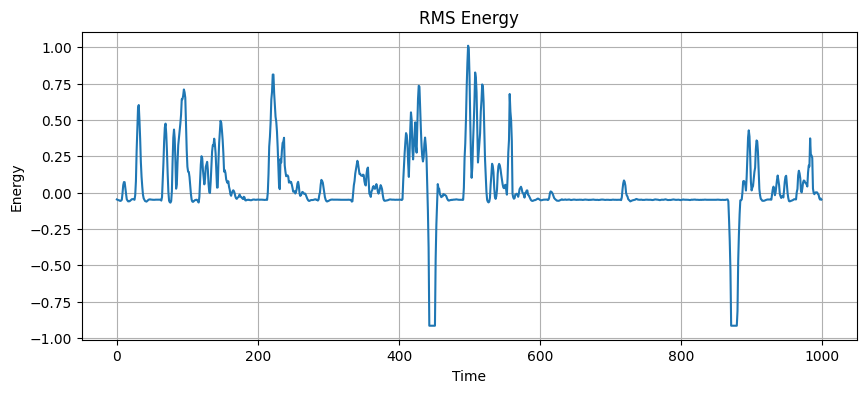

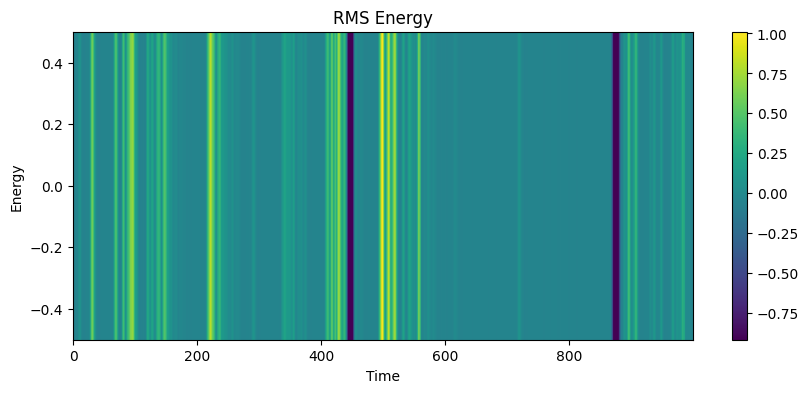

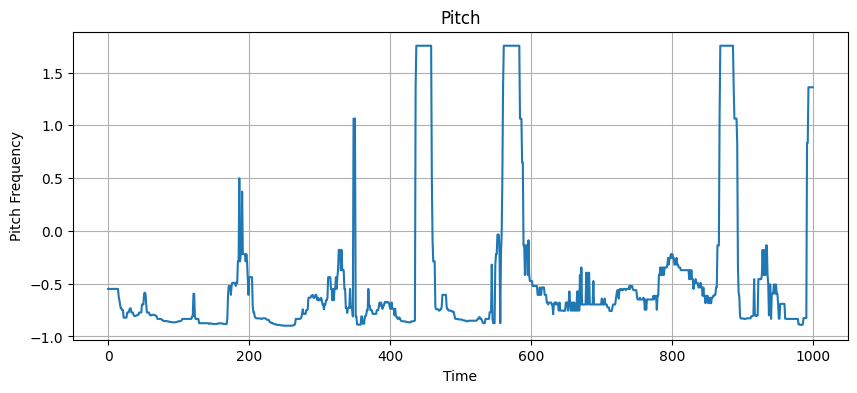

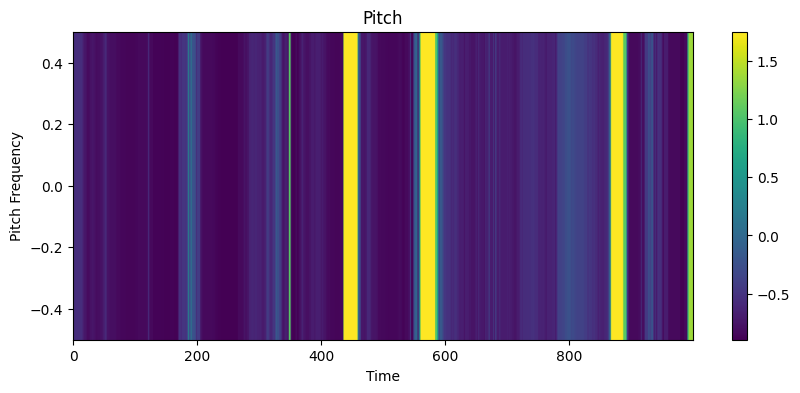

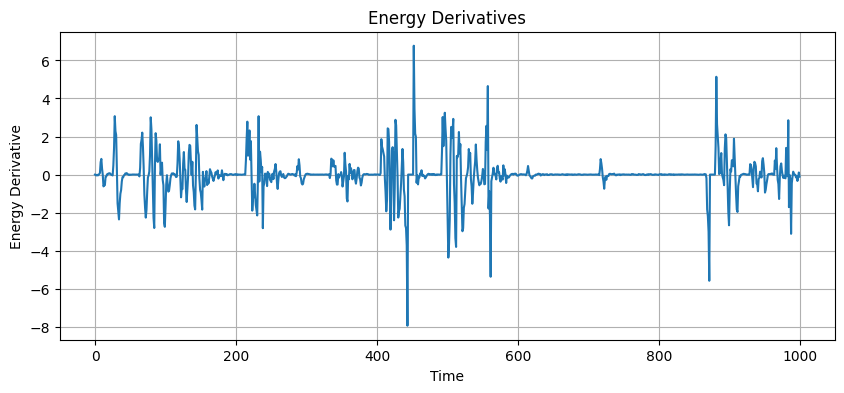

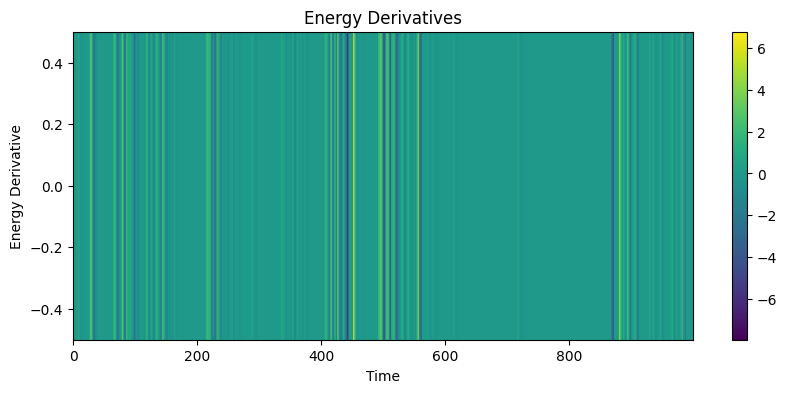

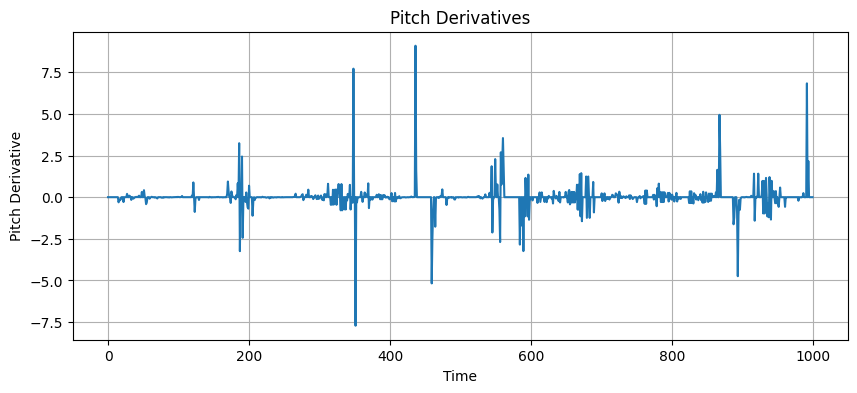

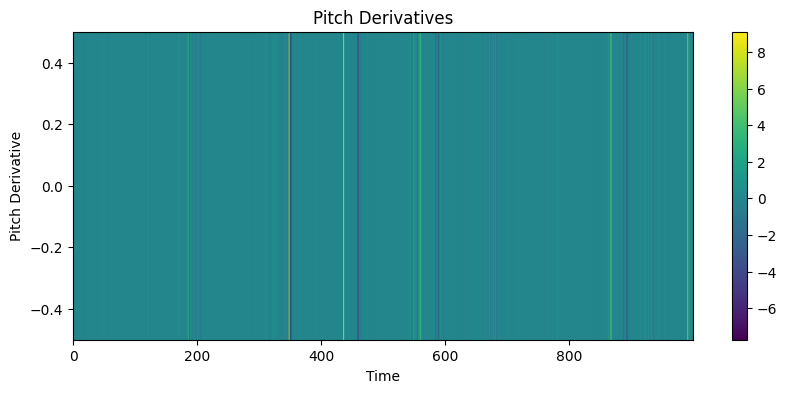

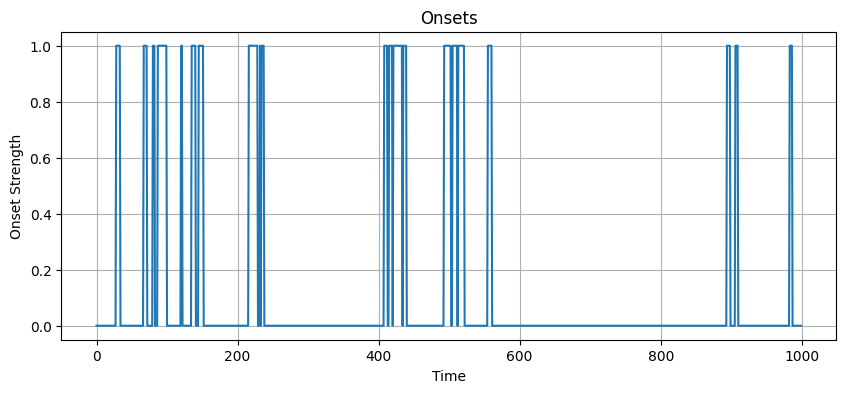

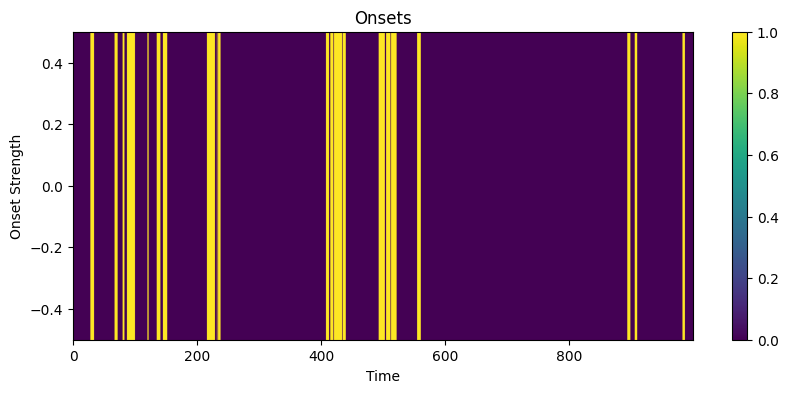

In [ ]:
# load the consolidated features file
# Load the entire dataset into RAM
import numpy as np
import torch

consolidated_file = 'dataset/genea2023_dataset/toy/main-agent/consolidated.npz'

data = np.load(consolidated_file)

# Convert to torch tensors for faster access
gestures = torch.from_numpy(data['gestures']).half()
mel_specs = torch.from_numpy(data['mel_spec']).half()
mfccs = torch.from_numpy(data['mfcc']).half()
rms_energies = torch.from_numpy(data['rms_energy']).half()
pitchs = torch.from_numpy(data['pitch']).half()
energy_derivatives = torch.from_numpy(data['energy_derivatives']).half()
pitch_derivatives = torch.from_numpy(data['pitch_derivatives']).half()
onsets = torch.from_numpy(data['onsets']).half()
wavlm_features = torch.from_numpy(data['wavlm_features']).half()
speakers = torch.from_numpy(data['speakers']).half()
# mean_pose = torch.from_numpy(data['mean_pose']).half()
# std_pose = torch.from_numpy(data['std_pose']).half()

# Close numpy file to free file handles
data.close()


print(f"Gestures shape: {gestures.shape}")
print(f"Mel Spectrogram shape: {mel_specs.shape}")
print(f"MFCC shape: {mfccs.shape}")
print(f"RMS Energy shape: {rms_energies.shape}")
print(f"Pitch shape: {pitchs.shape}")
print(f"Energy Derivatives shape: {energy_derivatives.shape}")
print(f"Pitch Derivatives shape: {pitch_derivatives.shape}")
print(f"Onsets shape: {onsets.shape}")
print(f"WavLM Features shape: {wavlm_features.shape}")
print(f"Speakers shape: {speakers.shape}")

# cat all the features into a single tensor
features = torch.cat([mel_specs, mfccs, rms_energies, pitchs, energy_derivatives, pitch_derivatives, onsets], dim=1)

print(f"All Features shape: {features.shape}")

# Draw features as an image
plt.figure(figsize=(20, 5))
plt.imshow(features[:, :].permute(1,0).cpu().numpy(), aspect='auto', origin='lower', vmin=-2.5, vmax=2.5)
plt.title('All Features')
plt.xlabel('Time')
plt.ylabel('Feature Type')
plt.colorbar()
plt.show()

# Draw the first 1000 frames of each feature
plot_feature(mel_specs[:1000, :].cpu().numpy(), 'Mel Spectrogram', 'Time', 'Mel Frequency')
plot_feature(mfccs[:1000, :].cpu().numpy(), 'MFCC', 'Time', 'MFCC Coefficients')
plot_feature(rms_energies[:1000, :].cpu().numpy(), 'RMS Energy', 'Time', 'Energy')
plot_feature(pitchs[:1000, :].cpu().numpy(), 'Pitch', 'Time', 'Pitch Frequency')
plot_feature(energy_derivatives[:1000, :].cpu().numpy(), 'Energy Derivatives', 'Time', 'Energy Derivative')
plot_feature(pitch_derivatives[:1000, :].cpu().numpy(), 'Pitch Derivatives', 'Time', 'Pitch Derivative')
plot_feature(onsets[:1000, :].cpu().numpy(), 'Onsets', 'Time', 'Onset Strength')